## 1)Qualitative data(categorical) DATA

## data that describe qualities or characteristics,and cannot be measured numerically,that data is known as categorical or qualitative dat


a)Nominal data:- categories with no inherent order

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
nominal_data=pd.Series(['Red','Blue','Green','Red','Blue','Red','Green','Blue','Red','Green','Blue'],name='Colors')
print(nominal_data)
print(nominal_data.value_counts())

0       Red
1      Blue
2     Green
3       Red
4      Blue
5       Red
6     Green
7      Blue
8       Red
9     Green
10     Blue
Name: Colors, dtype: object
Colors
Red      4
Blue     4
Green    3
Name: count, dtype: int64


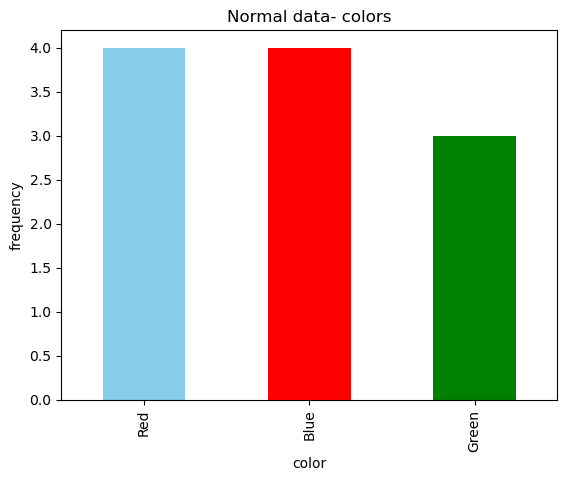

In [3]:
nominal_data.value_counts().plot(kind='bar',color=['skyblue','red','green'])
plt.title("Normal data- colors")
plt.xlabel('color')
plt.ylabel('frequency')
plt.show()

# Ordinal DATA:- Categories with a meaningfull order/ranking

In [4]:
ordinal_data=pd.Series(['Low','Medium','High','Medium','Low','High','High','Medium','Low','Medium','High'],name='Satisfaction')
# define order
order=['Low','Medium','High']
ordinal_data=pd.Categorical(ordinal_data,categories=order,ordered=True)
print(ordinal_data.value_counts().sort_index())

Low       3
Medium    4
High      4
Name: count, dtype: int64


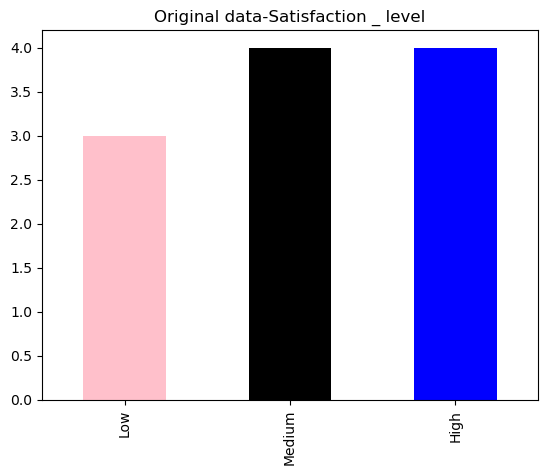

In [5]:
ordinal_data.value_counts().sort_index().plot(kind='bar',color=['pink','black','blue'])
plt.title("Original data-Satisfaction _ level")
plt.show()

# 2. Quantitative (Numerical) Data:

## Data that can be expressed numerically that is known as quantitative data or numerical data

a) Discrete Data:-countable values(whole number),often counts

In [6]:
import numpy as np
import seaborn as sns

In [7]:
np.random.seed(42)
discrete_data=pd.Series(np.random.randint(0,6,100),name='Children')
print(discrete_data)
print(discrete_data.describe())

0     3
1     4
2     2
3     4
4     4
     ..
95    3
96    3
97    4
98    0
99    4
Name: Children, Length: 100, dtype: int32
count    100.000000
mean       2.690000
std        1.624901
min        0.000000
25%        1.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: Children, dtype: float64


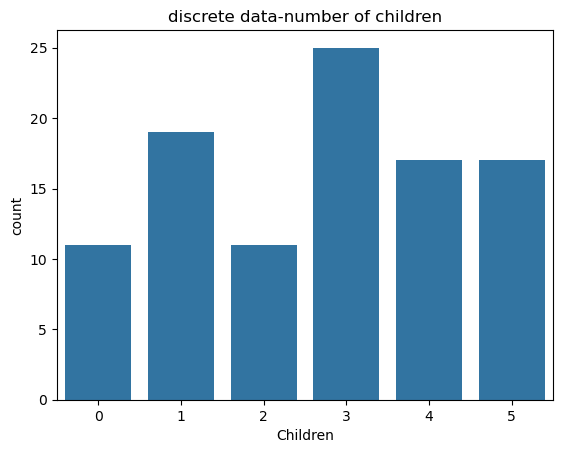

In [8]:
sns.countplot(x=discrete_data)
plt.title("discrete data-number of children")
plt.show()

# b)Continues Data: Any value within a range(can be decimal/fractional)

In [9]:
continuous_data=pd.Series(np.random.normal(170,10,1000),name='Height')
print(continuous_data)
print(continuous_data.describe())
print(continuous_data.mean())
print(continuous_data.median())
print(continuous_data.mode())

0      175.821228
1      178.877485
2      178.943323
3      177.549978
4      167.928341
          ...    
995    180.624015
996    147.655736
997    172.351998
998    158.444320
999    173.192233
Name: Height, Length: 1000, dtype: float64
count    1000.000000
mean      170.330785
std        10.005207
min       135.191912
25%       163.758937
50%       170.293021
75%       177.553362
max       203.722963
Name: Height, dtype: float64
170.33078512973998
170.2930209704749
0      135.191912
1      142.590452
2      143.406486
3      143.448240
4      144.972405
          ...    
995    196.435716
996    197.344222
997    197.837774
998    199.650104
999    203.722963
Name: Height, Length: 1000, dtype: float64


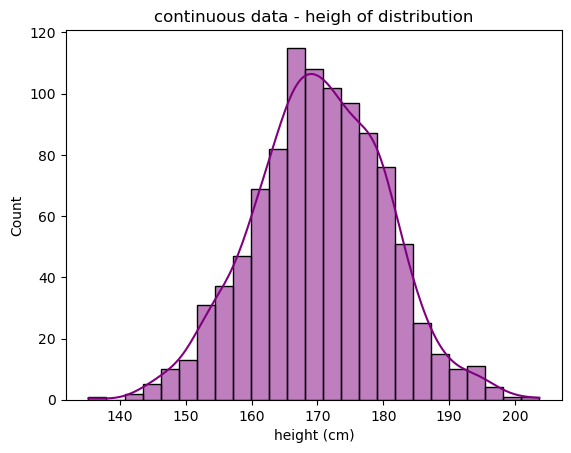

In [10]:
sns.histplot(continuous_data,kde=True,color='purple')
plt.title('continuous data - heigh of distribution')
plt.xlabel('height (cm)')
plt.show()

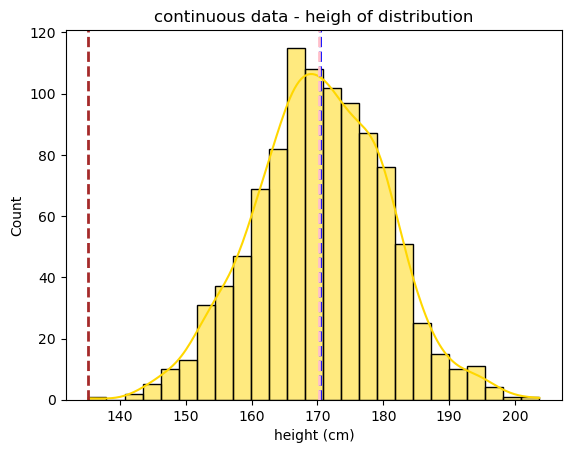

In [11]:
mean=continuous_data.mean()
median=continuous_data.median()
mode=continuous_data.mode()[0]
sns.histplot(continuous_data,kde=True,color='gold')
plt.axvline(mean,color='blue',linestyle='--',linewidth=2,label=f'mean={mean:.2f}')
plt.axvline(median,color='pink',linestyle='--',linewidth=2,label=f'median={median:.2f}')
plt.axvline(mode,color='brown',linestyle='--',linewidth=2,label=f'mode={mode:.2f}')

plt.title('continuous data - heigh of distribution')
plt.xlabel('height (cm)')
plt.show()

# normal distribution :- a distribution that shows how data values are spread acros a range,the KDE (kernel density estimate) is a sooth curve that estimate the probability of data like a smoothed histogram

## <font color='Orange'> the three key distribution are,
1.Normal(symmetric) (bell shaped) balanced both side                
2. right skewed (positive) long tail on right mean>median                  
3.left skewed(negative) long tail on left side mean<median

In [12]:
np.random.seed(42)
n=10000
normal_data=np.random.normal(loc=50,scale=10,size=n)
right_skewed=np.random.exponential(scale=10,size=n)+20
left_skewed=100-np.random.exponential(scale=10,size=n)

df= pd.DataFrame(
    {
        "Normal":normal_data,
        "Right_skewed":right_skewed,
        "left_skewed":left_skewed
    }
)

df.head()

,Normal,Right_skewed,left_skewed
0,54.967142,23.875100,98.118497
1,48.617357,21.087208,95.741247
2,56.476885,20.745162,64.900442
3,65.230299,20.990206,84.822847
4,47.658466,28.743558,96.678911


In [13]:
df.describe()

,Normal,Right_skewed,left_skewed
count,10000.000000,10000.000000,10000.000000
mean,49.978640,30.267338,90.132113
std,10.034624,10.252668,9.898607
min,10.775997,20.000481,17.751618
25%,43.274095,22.977891,86.474369
50%,49.974050,27.159437,93.134024
75%,56.710809,34.155229,97.149495
max,89.262377,114.957162,99.999325


In [14]:
print(df.skew())

Normal          0.001964
Right_skewed    1.997710
left_skewed    -2.004337
dtype: float64


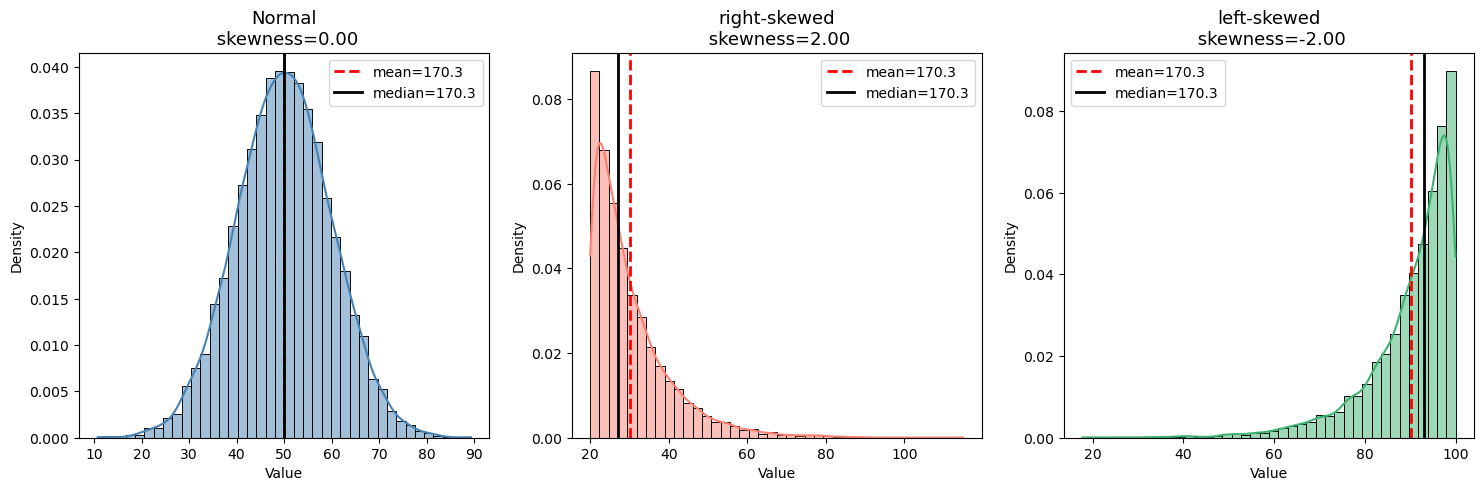

In [15]:
from scipy import stats
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(18,5))
datasets=[("Normal",normal_data,"steelblue"),
          ("right-skewed",right_skewed,"salmon"),
          ("left-skewed",left_skewed,"mediumseagreen")]
for ax,(title,data,color)in zip(axes,datasets):
    sns.histplot(data,kde=True,ax=ax,color=color,stat='density',bins=40,alpha=0.5)
    mean_value=np.mean(data)
    median_value=np.median(data)
    ax.axvline(mean_value,color='red',linestyle='--',linewidth=2,label=f'mean={mean:.1f}')
    ax.axvline(median_value,color='black',linestyle='-',linewidth=2,label=f'median={median:.1f}')
    skew=stats.skew(data)
    ax.set_title(f'{title}\n skewness={skew:.2f}',fontsize=13)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend()
plt.show()